# Exploration des données foudre — Meteorage
Analyse du fichier `segment_alerts_all_airports_train.csv`

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import des données

In [26]:
FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")

Fichier chargé avec succès


## 2. Aperçu général

In [27]:
print(f"Nombre de lignes    : {len(df):,}")
print(f"Nombre de colonnes  : {df.shape[1]}")
print(f"\nColonnes : {list(df.columns)}")

Nombre de lignes    : 507,071
Nombre de colonnes  : 13

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


In [28]:
# type des colonnes

df.dtypes

lightning_id                        int64
lightning_airport_id                int64
date                               object
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                            object
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

In [29]:
# conversion de "date" en type "datetime"
df['date'] = pd.to_datetime(df['date'], utc=True)

In [30]:
# les 5 premières valeurs

df.head()

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


## 3. Valeurs manquantes

In [31]:
missing = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values('pct_manquants (%)', ascending=False)
print(missing.to_string())

                                nb_manquants  pct_manquants (%)
airport_alert_id                      450472              88.84
is_last_lightning_cloud_ground        450472              88.84
date                                       0               0.00
lightning_airport_id                       0               0.00
lightning_id                               0               0.00
lat                                        0               0.00
lon                                        0               0.00
amplitude                                  0               0.00
maxis                                      0               0.00
dist                                       0               0.00
icloud                                     0               0.00
airport                                    0               0.00
azimuth                                    0               0.00


## 4. Statistiques descriptives

In [32]:
df.describe(include='all')

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
count,507071.000000,507071.000000,507071,507071.000000,507071.000000,507071.000000,507071.000000,507071,507071.000000,507071.000000,507071,56599.000000,56599
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,5,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,Pise,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,378079,NaN,NaN,156718,NaN,53972
mean,319152.873651,59451.210188,2019-03-27 03:35:05.546737920+00:00,6.385887,43.345451,-2.254868,1.025518,NaN,20.243757,168.806028,NaN,316.932720,NaN
min,1.000000,1.000000,2016-01-02 01:10:41+00:00,-2.006800,41.654300,-429.500000,0.016000,NaN,0.037212,0.000000,NaN,1.000000,NaN
25%,148099.500000,25354.000000,2017-06-28 16:02:00+00:00,-1.295800,42.471800,-5.610000,0.107000,NaN,15.412370,85.240722,NaN,170.000000,NaN
50%,317158.000000,54199.000000,2018-08-22 13:07:13+00:00,9.339100,43.445100,-1.560000,0.245000,NaN,21.442300,156.717299,NaN,282.000000,NaN
75%,501958.500000,90354.000000,2020-09-20 05:30:42+00:00,10.220500,43.666200,4.620000,1.538000,NaN,26.112228,251.482192,NaN,446.000000,NaN
max,628726.000000,156718.000000,2022-12-21 11:20:11+00:00,10.771700,47.422600,497.000000,6.900000,NaN,29.999996,359.978549,NaN,769.000000,NaN


In [33]:
# nombre d'éclairs en terme de distance

bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

result = dist_cat.value_counts().sort_index().to_frame(name='nb_eclairs')
result['pct (%)'] = (result['nb_eclairs'] / len(df) * 100).round(2)

result

,nb_eclairs,pct (%)
dist,,
< 20 km,220498,43.48
20-30 km,286573,56.52
> 30 km,0,0.00


In [34]:
# Pourcentage par type d'éclair
print("=== Type d'éclair ===")
type_result = df['icloud'].value_counts().to_frame(name='nb_eclairs')
type_result.index = ['Intra-nuage (True)', 'Nuage-sol (False)']
type_result['pct (%)'] = (type_result['nb_eclairs'] / len(df) * 100).round(2)
print(type_result)

=== Type d'éclair ===
                    nb_eclairs  pct (%)
Intra-nuage (True)      378079    74.56
Nuage-sol (False)       128992    25.44


In [35]:
# Croisement distance x type
print("\n=== Croisement distance x type ===")
bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

cross = pd.crosstab(dist_cat, df['icloud'], margins=True)
cross.columns = ['Nuage-sol', 'Intra-nuage', 'Total']
cross['pct_nuage_sol (%)'] = (cross['Nuage-sol'] / cross['Total'] * 100).round(2)
cross['pct_intra_nuage (%)'] = (cross['Intra-nuage'] / cross['Total'] * 100).round(2)

cross


=== Croisement distance x type ===


,Nuage-sol,Intra-nuage,Total,pct_nuage_sol (%),pct_intra_nuage (%)
dist,,,,,
< 20 km,56599,163899,220498,25.67,74.33
20-30 km,72393,214180,286573,25.26,74.74
All,128992,378079,507071,25.44,74.56


In [36]:
# stats sur la durée d'une alerte en minutes

# Filtrer les éclairs avec un alert_airport_id
alerts = df[df['airport_alert_id'].notna()].copy()

# Durée de chaque alerte = max(date) - min(date) par alerte
duree = alerts.groupby(['airport', 'airport_alert_id'])['date'].agg(
    debut='min',
    fin='max'
)

duree['duree_minutes'] = (duree['fin'] - duree['debut']).dt.total_seconds() / 60


print(f"Durée médiane d'une alerte : {duree['duree_minutes'].median():.2f} minutes")
print(f"Durée moyenne              : {duree['duree_minutes'].mean():.2f} minutes")
print(f"Durée min                  : {duree['duree_minutes'].min():.2f} minutes")
print(f"Durée max                  : {duree['duree_minutes'].max():.2f} minutes")

Durée médiane d'une alerte : 8.92 minutes
Durée moyenne              : 29.90 minutes
Durée min                  : 0.00 minutes
Durée max                  : 578.72 minutes


In [37]:
# Nombre d'alertes orageuses

nb_alertes = df.groupby(['airport', 'airport_alert_id']).ngroups
print(f"Nombre d'alertes orageuses : {nb_alertes}")
print(df.groupby("airport")["airport_alert_id"].nunique())

Nombre d'alertes orageuses : 2627
airport
Ajaccio     530
Bastia      532
Biarritz    590
Nantes      206
Pise        769
Name: airport_alert_id, dtype: int64


In [38]:
print(f"Lignes totales       : {len(df)}")
print(f"Colonnes             : {list(df.columns)}")
print(f"\nValeurs 'icloud' :")
print(df["icloud"].value_counts(dropna=False).to_string())
print(f"\nProportion IC (True) : {df['icloud'].astype(str).str.lower().eq('true').mean():.1%}")
 

Lignes totales       : 507071
Colonnes             : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']

Valeurs 'icloud' :
icloud
True     378079
False    128992

Proportion IC (True) : 74.6%


In [39]:
df_feat = pd.read_parquet("features.parquet")

# Récupérer la date du premier éclair CG de chaque alerte
first_cg = (
    df[df["icloud"] == False]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df["hour"] = df["t_start"].dt.hour
df["month"] = df["t_start"].dt.month
df["season"] = df["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

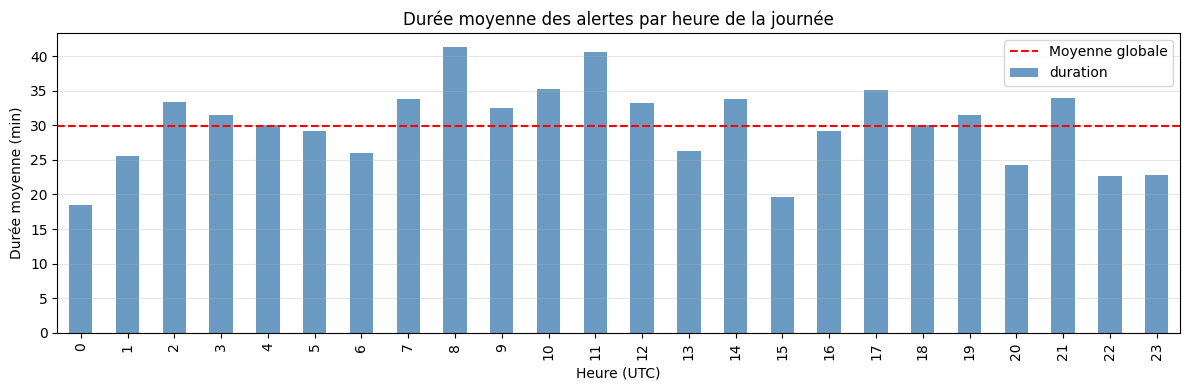

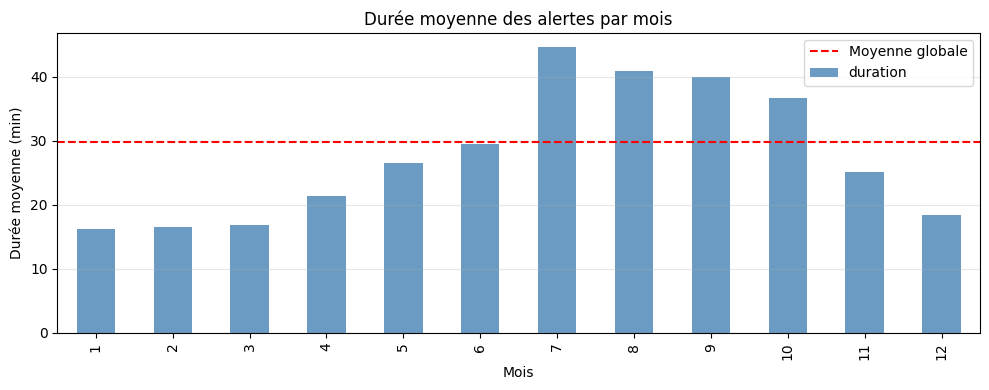

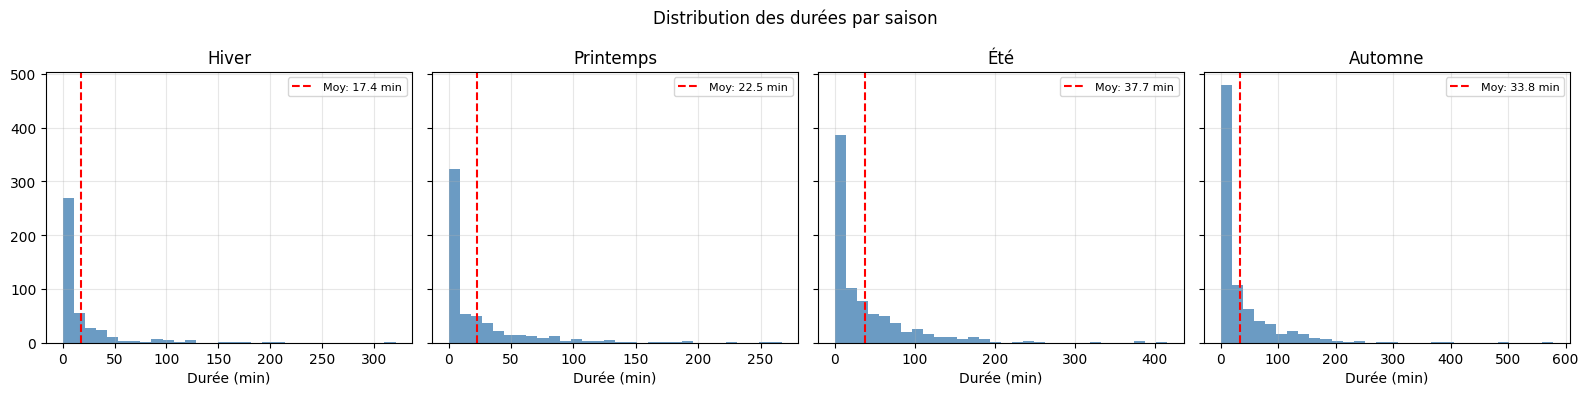

Durée moyenne par saison :
           mean  median  count
season                        
Automne    33.8    10.1    807
Hiver      17.4     2.6    419
Printemps  22.5     5.2    580
Été        37.7    16.8    821

Durée moyenne par heure (top 5 heures les plus longues) :
hour
8     41.3
11    40.6
10    35.2
17    35.0
21    33.9
Name: duration, dtype: float64

Correlation heure/durée : -0.004
Correlation mois/durée  : 0.066


In [40]:

# ── 1. Durée moyenne par heure ───────────────────────────────────────
plt.figure(figsize=(12, 4))
df.groupby("hour")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par heure de la journée")
plt.xlabel("Heure (UTC)")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 2. Durée moyenne par mois ────────────────────────────────────────
plt.figure(figsize=(10, 4))
df.groupby("month")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par mois")
plt.xlabel("Mois")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 3. Distribution des durées par saison ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, saison in zip(axes, ["Hiver", "Printemps", "Été", "Automne"]):
    data = df[df["season"] == saison]["duration"]
    ax.hist(data, bins=30, color="steelblue", alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f} min")
    ax.set_title(saison)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("Distribution des durées par saison")
plt.tight_layout()
plt.show()

# ── 4. Stats résumées ────────────────────────────────────────────────
print("Durée moyenne par saison :")
print(df.groupby("season")["duration"].agg(["mean", "median", "count"]).round(1))

print("\nDurée moyenne par heure (top 5 heures les plus longues) :")
print(df.groupby("hour")["duration"].mean().sort_values(ascending=False).head(5).round(1))

print("\nCorrelation heure/durée :", df["hour"].corr(df["duration"]).round(3))
print("Correlation mois/durée  :", df["month"].corr(df["duration"]).round(3))

          n_alerts  mean_duration  median_duration  std_duration
airport                                                         
Pise           769          33.10            11.30         54.15
Bastia         532          32.18            10.14         55.98
Ajaccio        530          28.52             8.38         45.30
Nantes         206          27.86             8.77         44.86
Biarritz       590          25.64             7.07         45.16


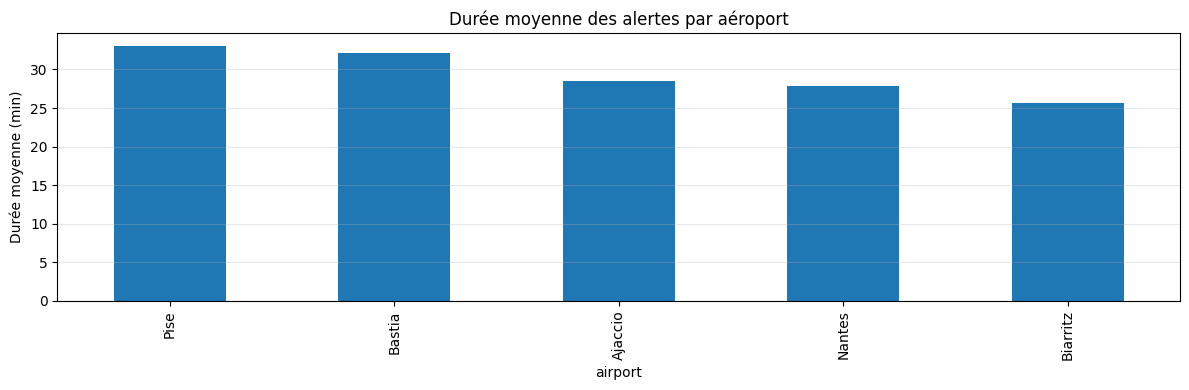

In [41]:
df_alerts = df.copy()
import pandas as pd
import matplotlib.pyplot as plt

# df_alerts : une ligne par alerte
# colonnes attendues : airport, airport_alert_id, duration

airport_stats = (
    df_alerts.groupby("airport")
    .agg(
        n_alerts=("airport_alert_id", "nunique"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        std_duration=("duration", "std"),
    )
    .sort_values("mean_duration", ascending=False)
)

print(airport_stats.round(2))

airport_stats["mean_duration"].plot(kind="bar", figsize=(12, 4))
plt.title("Durée moyenne des alertes par aéroport")
plt.ylabel("Durée moyenne (min)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

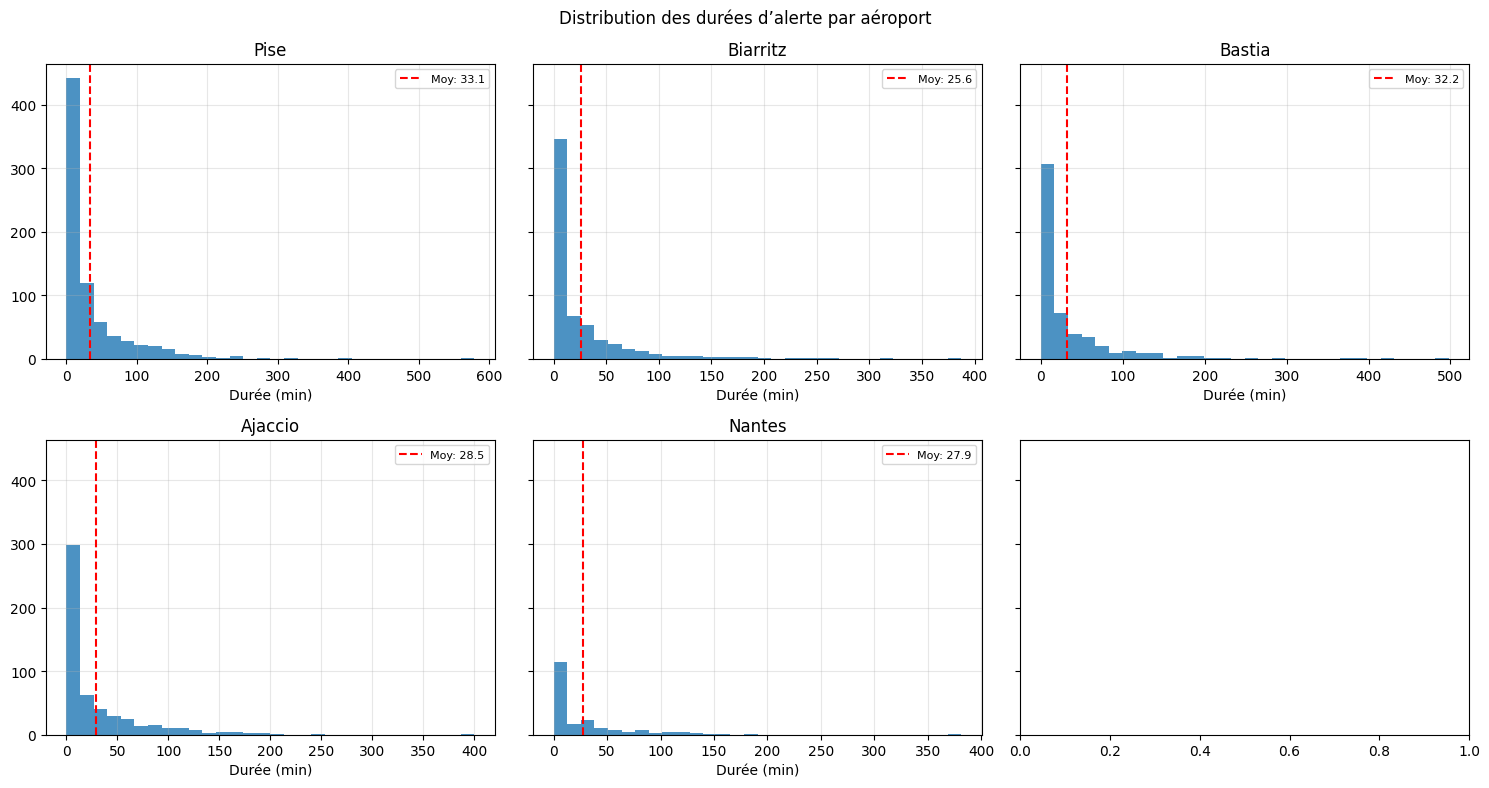

In [42]:
import matplotlib.pyplot as plt

top_airports = df_alerts["airport"].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=True)
axes = axes.ravel()

for ax, airport in zip(axes, top_airports):
    data = df_alerts.loc[df_alerts["airport"] == airport, "duration"]
    ax.hist(data, bins=30, alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f}")
    ax.set_title(airport)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution des durées d’alerte par aéroport")
plt.tight_layout()
plt.show()

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")
print(df.columns.tolist())
df.head()

Fichier chargé avec succès
['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [1]:
# À lancer une seule fois avant les analyses ci-dessous

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- brut événementiel ---
FILE_PATH = "segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(FILE_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# --- niveau alerte ---
df_feat = pd.read_parquet("features.parquet")

first_cg = (
    df_raw[(df_raw["type"] == "CG") & (df_raw["airport_alert_id"].notna())]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df_alerts = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df_alerts["hour"] = df_alerts["t_start"].dt.hour
df_alerts["month"] = df_alerts["t_start"].dt.month
df_alerts["season"] = df_alerts["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("df_raw :", df_raw.shape)
print("df_alerts :", df_alerts.shape)
print(df_alerts[["airport", "airport_alert_id", "duration", "hour", "month", "season"]].head())


df_raw : (507071, 15)
df_alerts : (2627, 67)
   airport  airport_alert_id  duration  hour  month season
0  Ajaccio               1.0  6.016667    21      1  Hiver
1  Ajaccio               2.0  0.000000     6      1  Hiver
2  Ajaccio               3.0  0.000000     7      1  Hiver
3  Ajaccio               4.0  0.000000    14      2  Hiver
4  Ajaccio               5.0  0.000000    14      2  Hiver


count    1682.00
mean        6.97
std         6.99
min         0.00
25%         2.00
50%         4.18
75%         9.80
max        29.65
Name: gap_before_last_cg_inner_min, dtype: float64


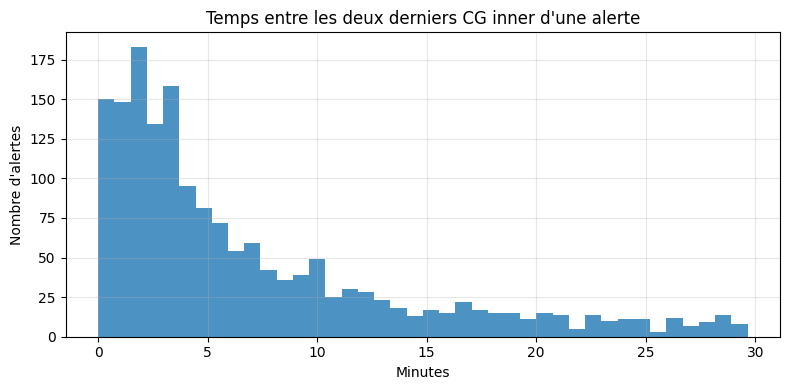

In [2]:
cg_inner = df_raw[
    (df_raw["type"] == "CG") &
    (df_raw["dist"] < 20) &
    (df_raw["airport_alert_id"].notna())
].copy()

last_two = (
    cg_inner.sort_values(["airport", "airport_alert_id", "date"])
    .groupby(["airport", "airport_alert_id"])["date"]
    .apply(lambda s: s.tail(2).tolist())
    .reset_index(name="last_two_dates")
)

def gap_last_two(x):
    if len(x) < 2:
        return np.nan
    return (x[-1] - x[-2]).total_seconds() / 60

last_two["gap_before_last_cg_inner_min"] = last_two["last_two_dates"].apply(gap_last_two)

print(last_two["gap_before_last_cg_inner_min"].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(last_two["gap_before_last_cg_inner_min"].dropna(), bins=40, alpha=0.8)
plt.title("Temps entre les deux derniers CG inner d'une alerte")
plt.xlabel("Minutes")
plt.ylabel("Nombre d'alertes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Q1.3 — contexte des 10 min avant le dernier CG inner (version rapide)

last_cg = (
    df_raw[
        (df_raw["type"] == "CG") &
        (df_raw["dist"] < 20) &
        (df_raw["airport_alert_id"].notna())
    ]
    .groupby(["airport", "airport_alert_id"], as_index=False)["date"]
    .max()
    .rename(columns={"date": "last_cg_time"})
)

ctx = (
    df_raw[df_raw["airport_alert_id"].notna()][["airport", "airport_alert_id", "date", "dist", "type"]]
    .merge(last_cg, on=["airport", "airport_alert_id"], how="inner")
)

ctx = ctx[
    (ctx["date"] <= ctx["last_cg_time"]) &
    (ctx["date"] > ctx["last_cg_time"] - pd.Timedelta(minutes=10))
].copy()

ctx["is_outer_20_30"] = (ctx["dist"] >= 20) & (ctx["dist"] < 30)
ctx["is_cg_outer_20_30"] = (ctx["type"] == "CG") & ctx["is_outer_20_30"]

df_lastcg_context = (
    ctx.groupby(["airport", "airport_alert_id", "last_cg_time"], as_index=False)
    .agg(
        n_total_last_10m_before_last_cg=("date", "size"),
        n_outer_last_10m_before_last_cg=("is_outer_20_30", "sum"),
        n_cg_outer_last_10m_before_last_cg=("is_cg_outer_20_30", "sum"),
        dist_min_last_10m_before_last_cg=("dist", "min"),
        dist_mean_last_10m_before_last_cg=("dist", "mean"),
    )
)

print(df_lastcg_context.head())
print(df_lastcg_context.describe(include="all"))

   airport  airport_alert_id              last_cg_time  \
0  Ajaccio               1.0 2016-01-02 21:28:54+00:00   
1  Ajaccio               2.0 2016-01-12 06:37:45+00:00   
2  Ajaccio               3.0 2016-01-12 07:25:37+00:00   
3  Ajaccio               4.0 2016-02-07 14:05:14+00:00   
4  Ajaccio               5.0 2016-02-07 14:35:39+00:00   

   n_total_last_10m_before_last_cg  n_outer_last_10m_before_last_cg  \
0                                5                                0   
1                                1                                0   
2                                1                                0   
3                                1                                0   
4                                1                                0   

   n_cg_outer_last_10m_before_last_cg  dist_min_last_10m_before_last_cg  \
0                                   0                         14.794117   
1                                   0                         12.875968   

In [6]:
alert_summary = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])
    .agg(
        n_events=("date", "size"),
        n_cg_inner=("dist", lambda s: ((df_raw.loc[s.index, "type"] == "CG") & (df_raw.loc[s.index, "dist"] < 20)).sum()),
        min_dist=("dist", "min"),
    )
    .reset_index()
)

alert_summary = alert_summary.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"],
    how="left"
)

print(alert_summary[["duration", "n_events", "n_cg_inner", "min_dist"]].corr().round(3))

            duration  n_events  n_cg_inner  min_dist
duration       1.000     0.654       0.654    -0.567
n_events       0.654     1.000       1.000    -0.327
n_cg_inner     0.654     1.000       1.000    -0.327
min_dist      -0.567    -0.327      -0.327     1.000


In [7]:
CLOSE_RADIUS_KM = 3.0

close_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_close=lambda x: (x["type"] == "CG") & (x["dist"] < CLOSE_RADIUS_KM))
    .groupby(["airport", "airport_alert_id"])["is_cg_close"]
    .max()
    .reset_index(name="has_close_cg")
)

print("Part globale d'alertes avec au moins un CG < 3 km :")
print(f"{100 * close_per_alert['has_close_cg'].mean():.2f}%")

print("\nPar aéroport :")
print((100 * close_per_alert.groupby('airport')["has_close_cg"].mean()).round(2).sort_values(ascending=False))

Part globale d'alertes avec au moins un CG < 3 km :
13.67%

Par aéroport :
airport
Nantes      17.48
Biarritz    14.07
Ajaccio     13.96
Pise        13.52
Bastia      11.65
Name: has_close_cg, dtype: float64


               mean  median  count
has_close_cg                      
False         19.01    4.57   2268
True          98.72   80.63    359


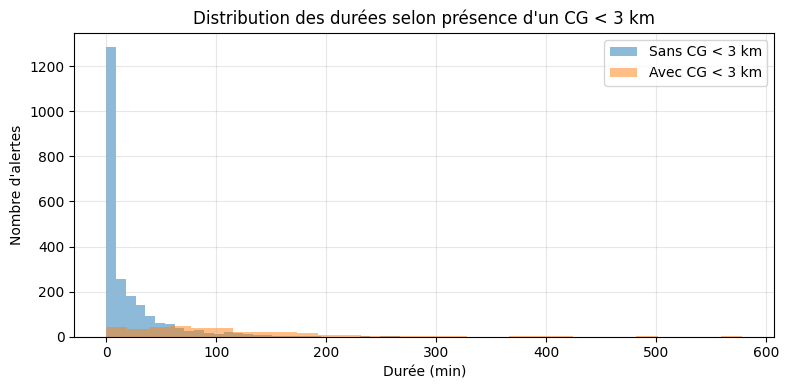

In [8]:
alert_close = df_alerts.merge(
    close_per_alert,
    on=["airport", "airport_alert_id"],
    how="left"
).fillna({"has_close_cg": 0})

print(
    alert_close.groupby("has_close_cg")["duration"]
    .agg(["mean", "median", "count"])
    .round(2)
)

plt.figure(figsize=(8, 4))
for label, val in [("Sans CG < 3 km", 0), ("Avec CG < 3 km", 1)]:
    data = alert_close.loc[alert_close["has_close_cg"] == val, "duration"].dropna()
    plt.hist(data, bins=30, alpha=0.5, label=label)

plt.title("Distribution des durées selon présence d'un CG < 3 km")
plt.xlabel("Durée (min)")
plt.ylabel("Nombre d'alertes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

count    2627.00
mean       10.89
std         5.95
min         0.04
25%         5.73
50%        11.51
75%        16.28
max        19.99
Name: min_dist, dtype: float64


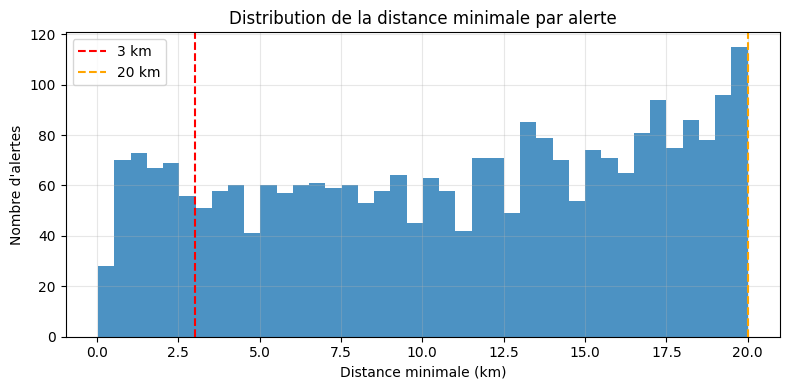

In [9]:
min_dist_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["dist"]
    .min()
    .reset_index(name="min_dist")
)

print(min_dist_per_alert["min_dist"].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(min_dist_per_alert["min_dist"], bins=40, alpha=0.8)
plt.axvline(3, color="red", linestyle="--", label="3 km")
plt.axvline(20, color="orange", linestyle="--", label="20 km")
plt.title("Distribution de la distance minimale par alerte")
plt.xlabel("Distance minimale (km)")
plt.ylabel("Nombre d'alertes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
cg_inner_counts = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum()
    .reset_index(name="n_cg_inner")
)

close_profile = (
    close_per_alert
    .merge(cg_inner_counts, on=["airport", "airport_alert_id"], how="left")
    .merge(df_alerts[["airport", "airport_alert_id", "duration"]], on=["airport", "airport_alert_id"], how="left")
)

print(close_profile.groupby("has_close_cg")[["n_cg_inner", "duration"]].agg(["mean", "median"]).round(2))

             n_cg_inner        duration       
                   mean median     mean median
has_close_cg                                  
False              7.18    2.0    19.01   4.57
True             112.33   45.0    98.72  80.63


In [11]:
airport_summary = (
    df_alerts.groupby("airport")
    .agg(
        n_alerts=("airport_alert_id", "nunique"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        std_duration=("duration", "std"),
    )
    .reset_index()
)

cg_inner_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum()
    .reset_index(name="n_cg_inner")
)

airport_cg = (
    cg_inner_per_alert.groupby("airport")["n_cg_inner"]
    .agg(mean_cg_inner="mean", median_cg_inner="median")
    .reset_index()
)

airport_min_dist = (
    min_dist_per_alert.groupby("airport")["min_dist"]
    .agg(mean_min_dist="mean", median_min_dist="median")
    .reset_index()
)

airport_close = (
    close_per_alert.groupby("airport")["has_close_cg"]
    .mean()
    .reset_index(name="rate_close_cg")
)

airport_full = (
    airport_summary
    .merge(airport_cg, on="airport", how="left")
    .merge(airport_min_dist, on="airport", how="left")
    .merge(airport_close, on="airport", how="left")
)

airport_full["rate_close_cg"] = 100 * airport_full["rate_close_cg"]

print(airport_full.round(2).sort_values("mean_duration", ascending=False))

    airport  n_alerts  mean_duration  median_duration  std_duration  \
4      Pise       769          33.10            11.30         54.15   
1    Bastia       532          32.18            10.14         55.98   
0   Ajaccio       530          28.52             8.38         45.30   
3    Nantes       206          27.86             8.77         44.86   
2  Biarritz       590          25.64             7.07         45.16   

   mean_cg_inner  median_cg_inner  mean_min_dist  median_min_dist  \
4          23.30              3.0          10.69            11.25   
1          25.83              3.0          11.36            12.22   
0          20.09              2.0          11.07            11.74   
3          21.25              2.0          10.42            11.11   
2          16.80              3.0          10.72            10.89   

   rate_close_cg  
4          13.52  
1          11.65  
0          13.96  
3          17.48  
2          14.07  


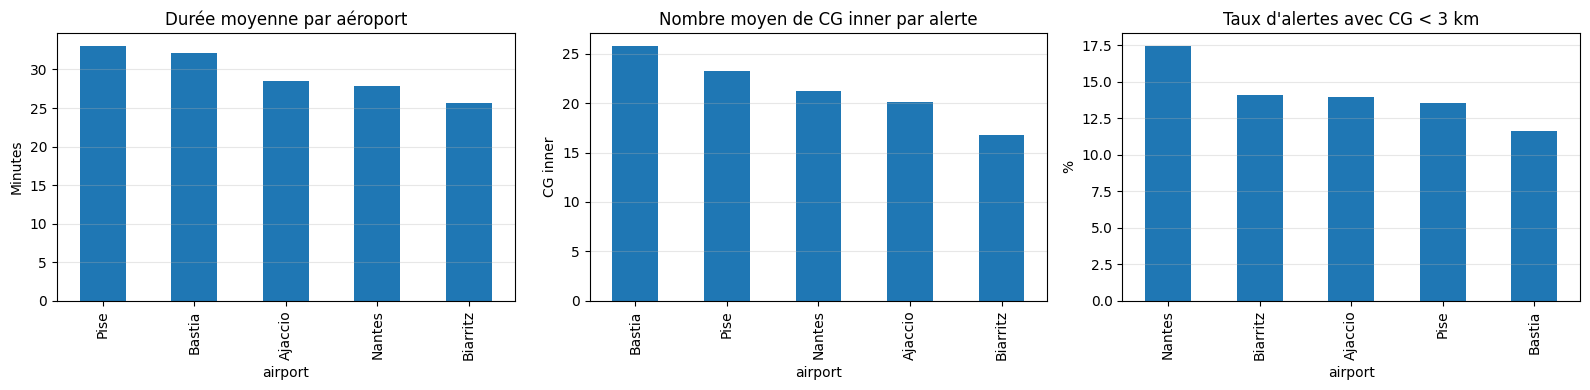

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

airport_full.sort_values("mean_duration", ascending=False).plot(
    x="airport", y="mean_duration", kind="bar", ax=axes[0], legend=False
)
axes[0].set_title("Durée moyenne par aéroport")
axes[0].set_ylabel("Minutes")
axes[0].grid(axis="y", alpha=0.3)

airport_full.sort_values("mean_cg_inner", ascending=False).plot(
    x="airport", y="mean_cg_inner", kind="bar", ax=axes[1], legend=False
)
axes[1].set_title("Nombre moyen de CG inner par alerte")
axes[1].set_ylabel("CG inner")
axes[1].grid(axis="y", alpha=0.3)

airport_full.sort_values("rate_close_cg", ascending=False).plot(
    x="airport", y="rate_close_cg", kind="bar", ax=axes[2], legend=False
)
axes[2].set_title("Taux d'alertes avec CG < 3 km")
axes[2].set_ylabel("%")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
alert_type_df = (
    df_alerts[["airport", "airport_alert_id", "duration"]]
    .merge(cg_inner_counts, on=["airport", "airport_alert_id"], how="left")
    .merge(min_dist_per_alert, on=["airport", "airport_alert_id"], how="left")
    .merge(close_per_alert, on=["airport", "airport_alert_id"], how="left")
)

# qcut robuste aux ex aequo
alert_type_df["duration_bin"] = pd.qcut(
    alert_type_df["duration"].rank(method="first"),
    q=3,
    labels=["courte", "moyenne", "longue"]
)

alert_type_df["cg_inner_bin"] = pd.qcut(
    alert_type_df["n_cg_inner"].rank(method="first"),
    q=3,
    labels=["faible", "moyen", "fort"]
)

alert_type_df["proximity_bin"] = pd.cut(
    alert_type_df["min_dist"],
    bins=[0, 3, 10, 20, np.inf],
    labels=["<3 km", "3-10 km", "10-20 km", ">20 km"],
    include_lowest=True
)

print(alert_type_df.head())

print("\nTypologie durée x intensité :")
print(pd.crosstab(alert_type_df["duration_bin"], alert_type_df["cg_inner_bin"]))

print("\nTypologie durée x proximité :")
print(pd.crosstab(alert_type_df["duration_bin"], alert_type_df["proximity_bin"]))

   airport  airport_alert_id  duration  n_cg_inner   min_dist  has_close_cg  \
0  Ajaccio               1.0  6.016667           5  14.794117         False   
1  Ajaccio               2.0  0.000000           1  12.875968         False   
2  Ajaccio               3.0  0.000000           1   6.347720         False   
3  Ajaccio               4.0  0.000000           1   3.033382         False   
4  Ajaccio               5.0  0.000000           1  17.927176         False   

  duration_bin cg_inner_bin proximity_bin  
0      moyenne        moyen      10-20 km  
1       courte       faible      10-20 km  
2       courte       faible       3-10 km  
3       courte       faible       3-10 km  
4       courte       faible      10-20 km  

Typologie durée x intensité :
cg_inner_bin  faible  moyen  fort
duration_bin                     
courte           857     19     0
moyenne           19    721   135
longue             0    135   741

Typologie durée x proximité :
proximity_bin  <3 km  3-10 km

In [15]:
type_by_airport = pd.crosstab(
    alert_type_df["airport"],
    alert_type_df["proximity_bin"],
    normalize="index"
) * 100

print(type_by_airport.round(1))

proximity_bin  <3 km  3-10 km  10-20 km
airport                                
Ajaccio         14.0     27.5      58.5
Bastia          11.7     29.1      59.2
Biarritz        14.1     31.7      54.2
Nantes          17.5     27.7      54.9
Pise            13.5     32.0      54.5


In [16]:
alert_local = alert_type_df.merge(
    df_alerts[["airport", "airport_alert_id", "hour", "month"]],
    on=["airport", "airport_alert_id"],
    how="left"
)

for airport, sub in alert_local.groupby("airport"):
    print(f"\n--- {airport} ---")
    print(sub[["duration", "n_cg_inner", "min_dist", "hour", "month"]].corr().round(2))


--- Ajaccio ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.60     -0.60  0.03   0.03
n_cg_inner      0.60        1.00     -0.40  0.00   0.03
min_dist       -0.60       -0.40      1.00 -0.05   0.02
hour            0.03        0.00     -0.05  1.00  -0.01
month           0.03        0.03      0.02 -0.01   1.00

--- Bastia ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.66     -0.55 -0.04   0.09
n_cg_inner      0.66        1.00     -0.29 -0.04   0.06
min_dist       -0.55       -0.29      1.00  0.00  -0.09
hour           -0.04       -0.04      0.00  1.00  -0.09
month           0.09        0.06     -0.09 -0.09   1.00

--- Biarritz ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.65     -0.55 -0.02  -0.03
n_cg_inner      0.65        1.00     -0.36  0.01  -0.04
min_dist       -0.55       -0.36      1.00  0.00  -0.00
hour           -0.02        0.01      0.00  1.00  -0.